# Fractal Number Robustness Experiment / Эксперимент устойчивости фрактального числа

In [1]:
from pathlib import Path
import sys, math, random
ROOT = Path.cwd()
if (ROOT / "snn_framework").exists(): sys.path.insert(0, str(ROOT))
elif (ROOT.parent / "snn_framework").exists(): sys.path.insert(0, str(ROOT.parent))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from snn_framework import MatrixFractalNumber

def print_table(rows, max_width=36):
    if not rows:
        print("<empty>"); return
    cols=list(rows[0].keys())
    def fmt(v):
        s=str(v); return s if len(s)<=max_width else s[:max_width-3]+'...'
    widths={c:max(len(str(c)), max(len(fmt(r.get(c,''))) for r in rows)) for c in cols}
    print(' | '.join(str(c).ljust(widths[c]) for c in cols))
    print('-+-'.join('-'*widths[c] for c in cols))
    for r in rows: print(' | '.join(fmt(r.get(c,'')).ljust(widths[c]) for c in cols))

def nonzero_windows(values):
    windows=[]; start=None
    for tick,value in enumerate(values):
        if abs(value)>1e-9 and start is None: start=tick
        elif abs(value)<=1e-9 and start is not None:
            windows.append((start,tick)); start=None
    if start is not None: windows.append((start,len(values)))
    return windows

def score_candidate(model, channel_signal, candidate):
    schedule=model.cell_schedule(candidate)
    observed=[v>0 for v in channel_signal]
    predicted=[schedule.is_active(t) for t in range(len(channel_signal))]
    hits=sum(int(o and p) for o,p in zip(observed,predicted))
    errors=sum(int(o!=p) for o,p in zip(observed,predicted))
    return hits, errors

In [2]:
SOURCE_NUMBER=2026; DIGIT_COUNT=4; PERIOD_LEVELS=2; SHIFT_LEVELS=4
NOISE_LEVELS=[0,5,10,20,30,40,50]; REPETITIONS=[1,2,4,8,16]; TRIALS=40
rng=np.random.default_rng(42)
def decode_noisy(model, noisy, digit_count):
    digits=[]
    for ch in range(digit_count):
        obs=[v>.5 for v in noisy[ch]]; best=None
        for cand in model.candidate_cells(ch):
            pred=[model.cell_schedule(cand).is_active(t) for t in range(len(obs))]
            hits=sum(int(o and p) for o,p in zip(obs,pred)); errors=sum(int(o!=p) for o,p in zip(obs,pred))
            row={"digit":cand.digit_value,"hits":hits,"errors":errors}
            if best is None or (row["errors"],-row["hits"]) < (best["errors"],-best["hits"]): best=row
        digits.append(best["digit"])
    return digits
def run_trial(repetitions,noise_percent):
    model=MatrixFractalNumber(PERIOD_LEVELS,SHIFT_LEVELS)
    cells=model.encode_cells(SOURCE_NUMBER,digit_count=DIGIT_COUNT); ticks=max(c.period_ticks for c in cells)*repetitions
    samples=model.signal(SOURCE_NUMBER,digit_count=DIGIT_COUNT,ticks=ticks)
    clean=np.array([[s.channel_amplitudes[ch] for s in samples] for ch in range(DIGIT_COUNT)],dtype=float)
    noisy=clean+rng.normal(0,noise_percent/100.0,size=clean.shape)
    decoded=model.decode_digits(decode_noisy(model,noisy,DIGIT_COUNT))
    return int(decoded==SOURCE_NUMBER)

In [3]:
rows=[]
for repetitions in REPETITIONS:
    for noise in NOISE_LEVELS:
        acc=float(np.mean([run_trial(repetitions,noise) for _ in range(TRIALS)]))
        rows.append({"activity":"half_period","repetitions":repetitions,"noise_percent":noise,"accuracy":acc,"error_rate":1-acc})
robustness_df=pd.DataFrame(rows)
print_table(robustness_df.head(20).to_dict("records"))

activity    | repetitions | noise_percent | accuracy | error_rate         
------------+-------------+---------------+----------+--------------------
half_period | 1           | 0             | 1.0      | 0.0                
half_period | 1           | 5             | 1.0      | 0.0                
half_period | 1           | 10            | 1.0      | 0.0                
half_period | 1           | 20            | 1.0      | 0.0                
half_period | 1           | 30            | 1.0      | 0.0                
half_period | 1           | 40            | 1.0      | 0.0                
half_period | 1           | 50            | 0.925    | 0.07499999999999996
half_period | 2           | 0             | 1.0      | 0.0                
half_period | 2           | 5             | 1.0      | 0.0                
half_period | 2           | 10            | 1.0      | 0.0                
half_period | 2           | 20            | 1.0      | 0.0                
half_period | 2          

In [4]:
threshold=.95
thr=[]
for repetitions,g in robustness_df.groupby("repetitions"):
    stable=g[g.accuracy>=threshold]
    thr.append({"activity":"half_period","repetitions":repetitions,"stable_until_noise_percent":None if stable.empty else int(stable.noise_percent.max())})
threshold_df=pd.DataFrame(thr); print("Stability threshold: accuracy >= 95%"); print_table(threshold_df.to_dict("records"))

Stability threshold: accuracy >= 95%
activity    | repetitions | stable_until_noise_percent
------------+-------------+---------------------------
half_period | 1           | 40                        
half_period | 2           | 50                        
half_period | 4           | 50                        
half_period | 8           | 50                        
half_period | 16          | 50                        


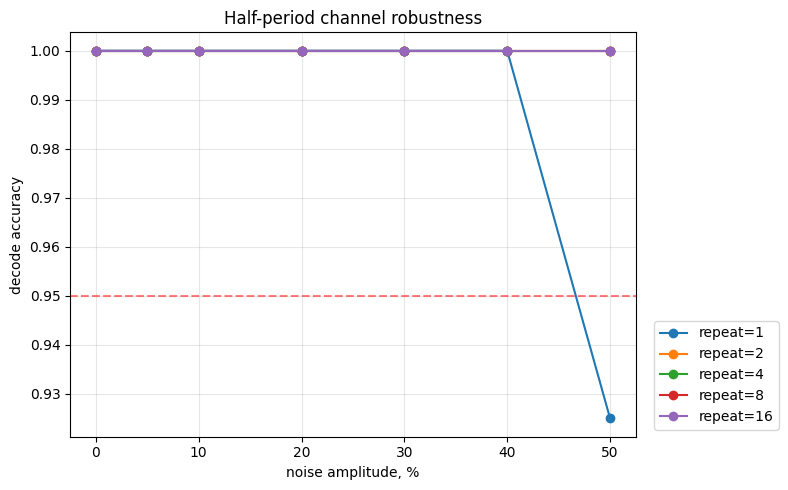

In [5]:
fig,ax=plt.subplots(1,1,figsize=(8,5))
for rep in REPETITIONS:
    g=robustness_df[robustness_df.repetitions==rep]
    ax.plot(g.noise_percent,g.accuracy,marker='o',label=f'repeat={rep}')
ax.axhline(.95,color='red',linestyle='--',alpha=.5); ax.set_title('Half-period channel robustness'); ax.set_xlabel('noise amplitude, %'); ax.grid(True,alpha=.3)
ax.set_ylabel('decode accuracy'); ax.legend(loc='lower left',bbox_to_anchor=(1.02,0)); plt.tight_layout(); plt.show()

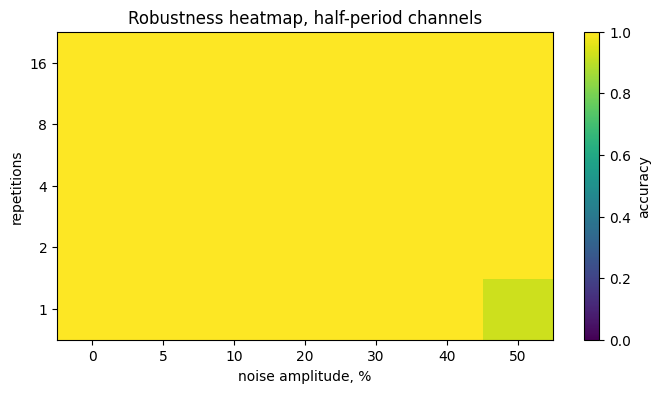

In [6]:
pivot=robustness_df.pivot(index='repetitions',columns='noise_percent',values='accuracy')
plt.figure(figsize=(8,4)); plt.imshow(pivot.values,aspect='auto',origin='lower',vmin=0,vmax=1); plt.colorbar(label='accuracy')
plt.xticks(range(len(pivot.columns)),pivot.columns); plt.yticks(range(len(pivot.index)),pivot.index)
plt.xlabel('noise amplitude, %'); plt.ylabel('repetitions'); plt.title('Robustness heatmap, half-period channels'); plt.show()